# Decision Trees 
## Topic: Spam vs Ham Email Classification

---

## 1. What is a Decision Tree?

A **Decision Tree** is a flowchart-like model that makes decisions step by step, just like a human would.

**Real-life analogy:**
```
Is it raining?
    YES → Take an umbrella
    NO  → Is it sunny?
              YES → Wear sunglasses
              NO  → Just go!
```

In Machine Learning, the tree **learns these rules automatically from data**.

---

## 2. Terminology (The Tree Anatomy)

```
                [Root Node]          ← First question / best split
               /           \
        [Branch]          [Branch]   ← Paths based on answer
           /                  \
    [Internal Node]      [Internal Node]  ← More questions
       /     \                /    \
   [Leaf]  [Leaf]         [Leaf]  [Leaf]  ← Final answer (class)
   SPAM     HAM            HAM    SPAM
```

| Term | Meaning |
|------|--------|
| Root Node | First split — most important feature |
| Internal Node | A question/condition |
| Branch | Outcome of a condition (Yes/No) |
| Leaf Node | Final class label (Spam or Ham) |
| Depth | Number of levels in the tree |

---

## 3. Why Use Decision Trees?

- Easy to **visualize and explain** — great for non-technical stakeholders
- Works on **both classification and regression** problems
- Handles **numerical and categorical data**
- **No feature scaling needed** (unlike SVM, KNN)
- Mirrors **human decision-making** logic

---

## 4. How Does a Decision Tree Learn?

The tree asks: **"Which feature splits the data in the most organized way?"**

It measures "organization" using:
- **Entropy** (used in ID3 algorithm)
- **Gini Impurity** (used in CART algorithm — sklearn default)

---

## 5. Entropy — The Measure of Chaos

**Simple Definition:** How mixed/impure a group is.

**Analogy:** Imagine a bag of marbles.
- Bag A: 10 red marbles → **Pure** → Entropy = 0
- Bag B: 5 red + 5 blue → **Totally Mixed** → Entropy = 1 (maximum)
- Bag C: 8 red + 2 blue → **Slightly Mixed** → Entropy ≈ 0.72

**Formula:**
```
Entropy = -Σ p(i) × log₂(p(i))
```

**Simple Example:**
- 4 Spam, 4 Ham emails → p(spam) = 0.5, p(ham) = 0.5
- Entropy = -(0.5 × log₂(0.5)) - (0.5 × log₂(0.5))
- Entropy = -(0.5 × -1) - (0.5 × -1) = 0.5 + 0.5 = **1.0** (maximum disorder)

- 8 Spam, 0 Ham → p(spam) = 1.0, p(ham) = 0
- Entropy = -(1 × log₂(1)) = -(1 × 0) = **0.0** (perfect purity)

**Key Rule:** Lower entropy = purer group = better split

---

## 6. Gini Impurity — Another Measure of Chaos

**Simple Definition:** Probability of incorrectly classifying a randomly chosen element.

**Formula:**
```
Gini = 1 - Σ p(i)²
```

**Simple Example:**
- 4 Spam, 4 Ham → p(spam) = 0.5, p(ham) = 0.5
- Gini = 1 - (0.5² + 0.5²) = 1 - (0.25 + 0.25) = **0.5** (max impurity for 2 classes)

- 8 Spam, 0 Ham → p(spam) = 1.0
- Gini = 1 - (1.0²) = 1 - 1 = **0.0** (pure!)

| Metric | Range | Pure = | Impure = |
|--------|-------|--------|----------|
| Entropy | 0 to 1 | 0 | 1 |
| Gini | 0 to 0.5 | 0 | 0.5 |

**Both measure the same thing — just different math. Gini is faster (no log calculation).**

---

## 7. Information Gain — Choosing the Best Split

**Definition:** How much does a feature REDUCE the entropy/chaos?

**Formula:**
```
Information Gain = Entropy(Parent) - Weighted Average Entropy(Children)
```

**Step-by-Step Example (Spam Detection):**

Suppose we have 10 emails: 5 Spam, 5 Ham

**Parent Entropy:**
```
p(spam) = 5/10 = 0.5
p(ham)  = 5/10 = 0.5
Entropy(parent) = -(0.5 × log₂(0.5)) - (0.5 × log₂(0.5)) = 1.0
```

**Feature: Contains word "FREE"?**
```
FREE = YES → 4 Spam, 1 Ham  (5 emails)
FREE = NO  → 1 Spam, 4 Ham  (5 emails)
```

**Entropy of Left Child (FREE=YES):**
```
p(spam) = 4/5 = 0.8,  p(ham) = 1/5 = 0.2
Entropy = -(0.8 × log₂(0.8)) - (0.2 × log₂(0.2))
        = -(0.8 × -0.322) - (0.2 × -2.322)
        = 0.258 + 0.464 = 0.722
```

**Entropy of Right Child (FREE=NO):**
```
p(spam) = 1/5 = 0.2,  p(ham) = 4/5 = 0.8
Entropy = same by symmetry = 0.722
```

**Weighted Average Entropy:**
```
= (5/10 × 0.722) + (5/10 × 0.722) = 0.722
```

**Information Gain:**
```
IG = 1.0 - 0.722 = 0.278
```

The tree picks the feature with the **highest Information Gain** as the root.

- Parent entropy = how messy things were before splitting
- Weighted child entropy = how messy things are after splitting
- IG = improvement = before − after
---

## 8. Overfitting — The Big Problem

### What is Overfitting?

The tree **memorizes training data** instead of **learning patterns**.

**Analogy:**
> A student who memorizes all past exam questions word-for-word but can't answer a slightly different question. vs. A student who understands the concept and can handle any variation.

### When Does Overfitting Happen in Decision Trees?

| Cause | Effect |
|-------|--------|
| Tree grows too deep | One leaf per training sample |
| No minimum samples limit | Creates splits for just 1-2 samples |
| No max features limit | Uses noisy/irrelevant features |
| Small dataset | Tree memorizes noise |

**Visualization:**
```
OVERFIT TREE (depth=unlimited):          GOOD TREE (depth=3):

Training Accuracy: 100%                  Training Accuracy: 92%
Test Accuracy:      55%  ← BAD!          Test Accuracy:     89%  ← GOOD!
```

### How to Fix Overfitting:
1. **max_depth** — limit how deep the tree can grow
2. **min_samples_split** — minimum samples needed to make a split
3. **min_samples_leaf** — minimum samples in a leaf node
4. **Pruning** — cut back branches after tree is grown
5. **Use Random Forest** — ensemble of many trees

---

## 9. Why We Need Visibility (Interpretability)

Decision Trees are the **most interpretable ML model**.

**Why visibility matters:**
- **Banking/Finance:** "Why was my loan rejected?" — Must explain
- **Healthcare:** "Why is this patient high risk?" — Must explain
- **Legal:** Many countries require explainable AI decisions
- **Debugging:** You can see EXACTLY why a prediction was made

**Example explanation from tree:**
> "This email is SPAM because:
> 1. It contains the word 'FREE' ✓
> 2. It has more than 3 exclamation marks ✓
> 3. Sender is not in contact list ✓"

Black-box models (Neural Networks) cannot give such explanations.

---

## 10. Advantages and Disadvantages

### Advantages
| # | Advantage | Why it matters |
|---|-----------|----------------|
| 1 | Easy to visualize | Non-technical people can understand |
| 2 | No data preprocessing needed | No scaling, no normalization |
| 3 | Handles missing values | Robust to incomplete data |
| 4 | Works on numeric & categorical | Flexible input types |
| 5 | Fast prediction | Just follow the tree path |
| 6 | Identifies important features | Feature importance scores |

### Disadvantages
| # | Disadvantage | Solution |
|---|-------------|----------|
| 1 | Overfits easily | Pruning, max_depth |
| 2 | Unstable (small data change = different tree) | Random Forest |
| 3 | Biased toward features with more levels | Use Gini or normalized IG |
| 4 | Not great for regression | Use Gradient Boosting |
| 5 | Cannot extrapolate | Only predicts within training range |

---

## 11. Real-World Uses

| Domain | Use Case |
|--------|----------|
| Email | Spam vs Ham detection |
| Banking | Loan approval / fraud detection |
| Healthcare | Disease diagnosis |
| Retail | Customer churn prediction |
| HR | Employee attrition |
| Manufacturing | Defect detection |


---
# Implementation: Spam vs Ham Detection
---

In [1]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Step 2: Create a Realistic Spam/Ham Dataset
# Features extracted from email content

np.random.seed(42)

n_spam = 100
n_ham  = 100

# SPAM emails: lots of exclamation, free/win/prize words, unknown senders, short subject
spam_data = {
    'has_free_word':       np.random.choice([1, 0], n_spam, p=[0.85, 0.15]),
    'has_win_prize':       np.random.choice([1, 0], n_spam, p=[0.80, 0.20]),
    'exclamation_count':   np.random.randint(3, 10, n_spam),
    'is_known_sender':     np.random.choice([1, 0], n_spam, p=[0.10, 0.90]),
    'has_suspicious_link': np.random.choice([1, 0], n_spam, p=[0.75, 0.25]),
    'word_count':          np.random.randint(20, 80, n_spam),
    'label': ['spam'] * n_spam
}

# HAM emails: normal language, known senders, fewer exclamations
ham_data = {
    'has_free_word':       np.random.choice([1, 0], n_ham, p=[0.10, 0.90]),
    'has_win_prize':       np.random.choice([1, 0], n_ham, p=[0.05, 0.95]),
    'exclamation_count':   np.random.randint(0, 3, n_ham),
    'is_known_sender':     np.random.choice([1, 0], n_ham, p=[0.85, 0.15]),
    'has_suspicious_link': np.random.choice([1, 0], n_ham, p=[0.10, 0.90]),
    'word_count':          np.random.randint(50, 300, n_ham),
    'label': ['ham'] * n_ham
}

df = pd.concat([
    pd.DataFrame(spam_data),
    pd.DataFrame(ham_data)
], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['label'].value_counts())
df.head(10)

Dataset shape: (200, 7)

Class distribution:
spam    100
ham     100
Name: label, dtype: int64


,has_free_word,has_win_prize,exclamation_count,is_known_sender,has_suspicious_link,word_count,label
0,1,1,8,0,1,69,spam
1,1,0,4,0,1,64,spam
2,1,1,3,0,1,76,spam
3,0,1,1,1,0,192,ham
4,0,0,0,1,0,150,ham
5,0,0,0,1,0,88,ham
6,0,1,5,0,0,60,spam
7,0,0,0,1,0,200,ham
8,0,0,0,1,0,299,ham
9,1,1,5,0,1,76,spam


In [3]:
# Step 3: Manual Entropy & Gini Calculation (for teaching)

def compute_entropy(labels):
    """Entropy: measures disorder in a group."""
    n = len(labels)
    if n == 0:
        return 0
    counts = pd.Series(labels).value_counts()
    probs = counts / n
    entropy = -np.sum(probs * np.log2(probs + 1e-10))
    return round(entropy, 4)

def compute_gini(labels):
    """Gini Impurity: probability of wrong classification."""
    n = len(labels)
    if n == 0:
        return 0
    counts = pd.Series(labels).value_counts()
    probs = counts / n
    gini = 1 - np.sum(probs ** 2)
    return round(gini, 4)

def compute_information_gain(parent_labels, left_labels, right_labels):
    """IG = Entropy(parent) - weighted entropy(children)."""
    n = len(parent_labels)
    n_left  = len(left_labels)
    n_right = len(right_labels)

    parent_entropy = compute_entropy(parent_labels)
    left_entropy   = compute_entropy(left_labels)
    right_entropy  = compute_entropy(right_labels)

    weighted_child_entropy = (n_left/n) * left_entropy + (n_right/n) * right_entropy
    ig = parent_entropy - weighted_child_entropy
    return round(ig, 4)

# === DEMO ===
all_labels = df['label'].tolist()

print("=" * 55)
print("MANUAL CALCULATION DEMO")
print("=" * 55)
print(f"\nParent Dataset: {len(all_labels)} emails")
print(f"  → {all_labels.count('spam')} Spam, {all_labels.count('ham')} Ham")
print(f"  → Entropy  = {compute_entropy(all_labels)}")
print(f"  → Gini     = {compute_gini(all_labels)}")

# Split on 'has_free_word'
left  = df[df['has_free_word'] == 1]['label'].tolist()   # has FREE
right = df[df['has_free_word'] == 0]['label'].tolist()   # no FREE

print(f"\nSplit on 'has_free_word':")
print(f"  LEFT  (FREE=YES): {len(left)} emails → spam={left.count('spam')}, ham={left.count('ham')}")
print(f"    → Entropy = {compute_entropy(left)}, Gini = {compute_gini(left)}")
print(f"  RIGHT (FREE=NO) : {len(right)} emails → spam={right.count('spam')}, ham={right.count('ham')}")
print(f"    → Entropy = {compute_entropy(right)}, Gini = {compute_gini(right)}")
print(f"\n  Information Gain = {compute_information_gain(all_labels, left, right)}")

MANUAL CALCULATION DEMO

Parent Dataset: 200 emails
  → 100 Spam, 100 Ham
  → Entropy  = 1.0
  → Gini     = 0.5

Split on 'has_free_word':
  LEFT  (FREE=YES): 99 emails → spam=87, ham=12
    → Entropy = 0.5328, Gini = 0.213
  RIGHT (FREE=NO) : 101 emails → spam=13, ham=88
    → Entropy = 0.5539, Gini = 0.2243

  Information Gain = 0.4565


In [4]:
# Step 4: Compare Information Gain for ALL Features

features = ['has_free_word', 'has_win_prize', 'exclamation_count',
            'is_known_sender', 'has_suspicious_link', 'word_count']

print("=" * 60)
print("INFORMATION GAIN — Which Feature is BEST to Split On?")
print("=" * 60)
print(f"{'Feature':<25} {'Info Gain':>10}")
print("-" * 40)

ig_scores = {}
for feat in features:
    # Binary split at median
    threshold = df[feat].median()
    left_labels  = df[df[feat] <= threshold]['label'].tolist()
    right_labels = df[df[feat] >  threshold]['label'].tolist()
    ig = compute_information_gain(all_labels, left_labels, right_labels)
    ig_scores[feat] = ig
    marker = " ← BEST SPLIT" if ig == max(ig_scores.values()) else ""
    print(f"{feat:<25} {ig:>10.4f}{marker}")

best_feature = max(ig_scores, key=ig_scores.get)
print(f"\nTree will split on: '{best_feature}' first (highest IG)")

INFORMATION GAIN — Which Feature is BEST to Split On?
Feature                    Info Gain
----------------------------------------
has_free_word                 0.4565 ← BEST SPLIT
has_win_prize                 0.4153
exclamation_count             1.0000 ← BEST SPLIT
is_known_sender               0.0000
has_suspicious_link           0.3328
word_count                    0.4426

Tree will split on: 'exclamation_count' first (highest IG)


In [5]:
# Step 5: Train Decision Tree Models

X = df[features]
le = LabelEncoder()
y = le.fit_transform(df['label'])  # ham=0, spam=1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Model 1: Overfit tree (no constraints) ---
dt_overfit = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_overfit.fit(X_train, y_train)

# --- Model 2: Good tree (controlled depth) ---
dt_good = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt_good.fit(X_train, y_train)

# --- Results ---
print("=" * 60)
print("OVERFITTING DEMONSTRATION")
print("=" * 60)
print(f"\nOVERFIT Tree (no constraints, depth={dt_overfit.get_depth()}):")
print(f"  Train Accuracy : {accuracy_score(y_train, dt_overfit.predict(X_train)):.1%}")
print(f"  Test  Accuracy : {accuracy_score(y_test,  dt_overfit.predict(X_test)):.1%}  ← drops!")

print(f"\nGOOD Tree (max_depth=4, depth={dt_good.get_depth()}):")
print(f"  Train Accuracy : {accuracy_score(y_train, dt_good.predict(X_train)):.1%}")
print(f"  Test  Accuracy : {accuracy_score(y_test,  dt_good.predict(X_test)):.1%}  ← stays high!")

print("\n→ When Train >> Test accuracy, the tree is OVERFITTING")

OVERFITTING DEMONSTRATION

OVERFIT Tree (no constraints, depth=1):
  Train Accuracy : 100.0%
  Test  Accuracy : 100.0%  ← drops!

GOOD Tree (max_depth=4, depth=1):
  Train Accuracy : 100.0%
  Test  Accuracy : 100.0%  ← stays high!

→ When Train >> Test accuracy, the tree is OVERFITTING


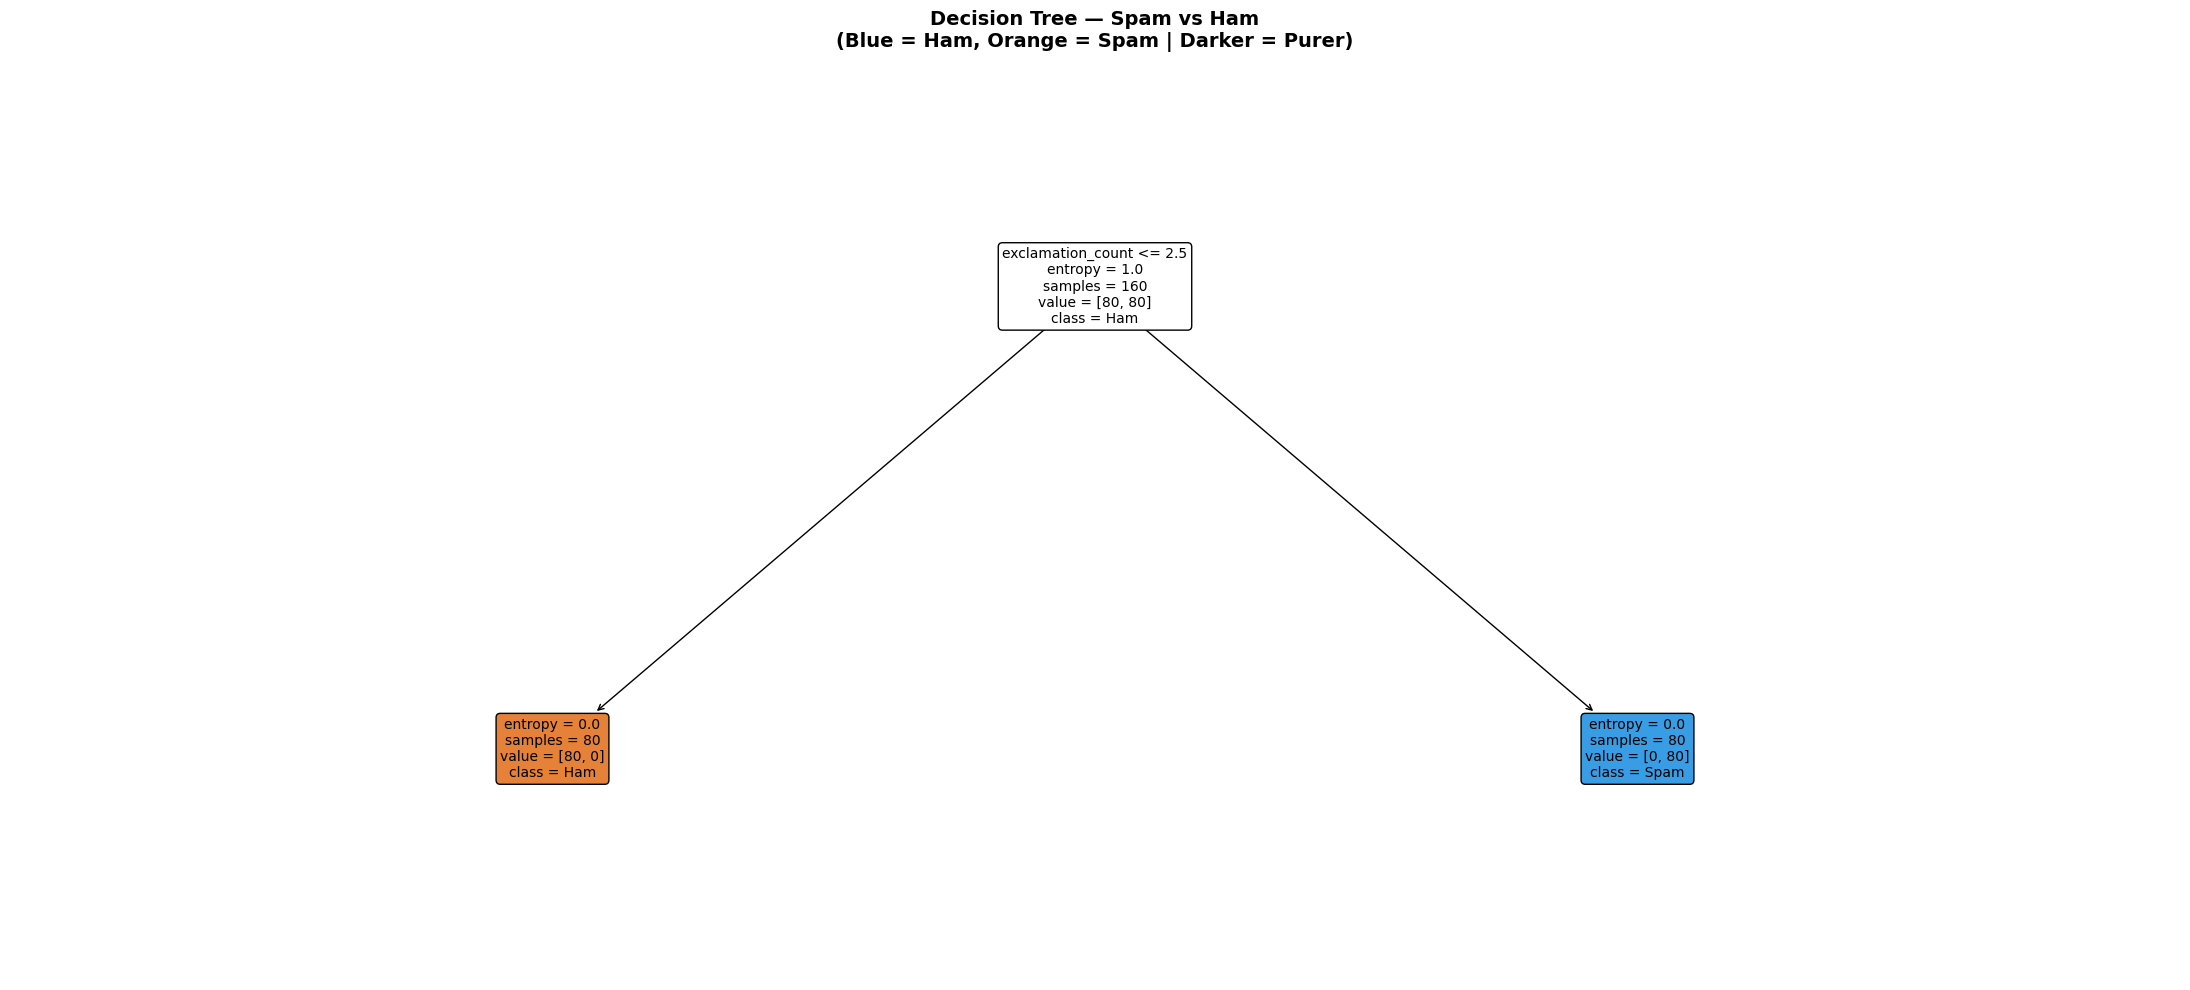


Saved as 'decision_tree_spam_ham.png'


In [6]:
# Step 6: Visualize the Decision Tree

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_good,
    feature_names=features,
    class_names=['Ham', 'Spam'],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title(
    "Decision Tree — Spam vs Ham\n"
    "(Blue = Ham, Orange = Spam | Darker = Purer)",
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('decision_tree_spam_ham.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nSaved as 'decision_tree_spam_ham.png'")

In [7]:
# Step 7: Text Representation of Tree (for teaching)

print("DECISION TREE — TEXT FORMAT (first 3 levels)")
print("=" * 60)
print(export_text(dt_good, feature_names=features, max_depth=3))
print("\nReading guide:")
print("  |--- feature <= value  → YES branch")
print("  |--- feature >  value  → NO branch")
print("  |--- class: 0 = Ham, 1 = Spam")

DECISION TREE — TEXT FORMAT (first 3 levels)
|--- exclamation_count <= 2.50
|   |--- class: 0
|--- exclamation_count >  2.50
|   |--- class: 1


Reading guide:
  |--- feature <= value  → YES branch
  |--- feature >  value  → NO branch
  |--- class: 0 = Ham, 1 = Spam


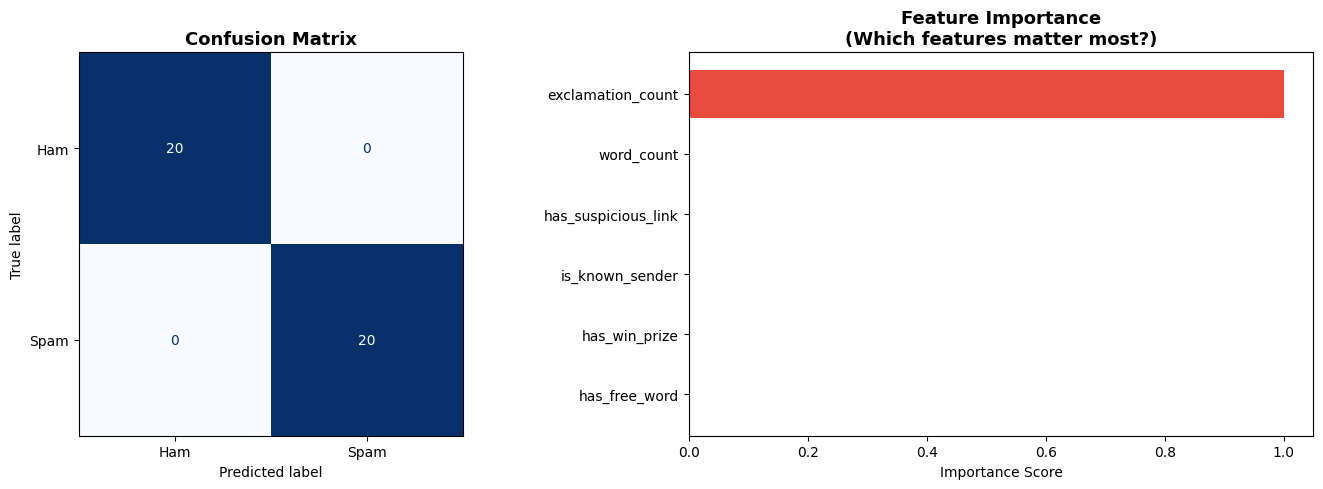


CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00        20
        Spam       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40


READING THE CONFUSION MATRIX:
  True Negative  (Ham  → Ham)  : 20  ✓
  False Positive (Ham  → Spam) : 0  ← Normal email blocked (False Alarm)
  False Negative (Spam → Ham)  : 0  ← Spam not caught (Missed)
  True Positive  (Spam → Spam) : 20  ✓


In [8]:
# Step 8: Confusion Matrix & Classification Report

y_pred = dt_good.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# Feature Importance
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': dt_good.feature_importances_
}).sort_values('Importance', ascending=True)

colors = ['#e74c3c' if i > importance_df['Importance'].median() else '#3498db'
          for i in importance_df['Importance']]
axes[1].barh(importance_df['Feature'], importance_df['Importance'], color=colors)
axes[1].set_xlabel('Importance Score')
axes[1].set_title('Feature Importance\n(Which features matter most?)', fontsize=13, fontweight='bold')
axes[1].axvline(importance_df['Importance'].median(), color='gray', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('confusion_and_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nCLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

print("\nREADING THE CONFUSION MATRIX:")
print(f"  True Negative  (Ham  → Ham)  : {cm[0,0]}  ✓")
print(f"  False Positive (Ham  → Spam) : {cm[0,1]}  ← Normal email blocked (False Alarm)")
print(f"  False Negative (Spam → Ham)  : {cm[1,0]}  ← Spam not caught (Missed)")
print(f"  True Positive  (Spam → Spam) : {cm[1,1]}  ✓")

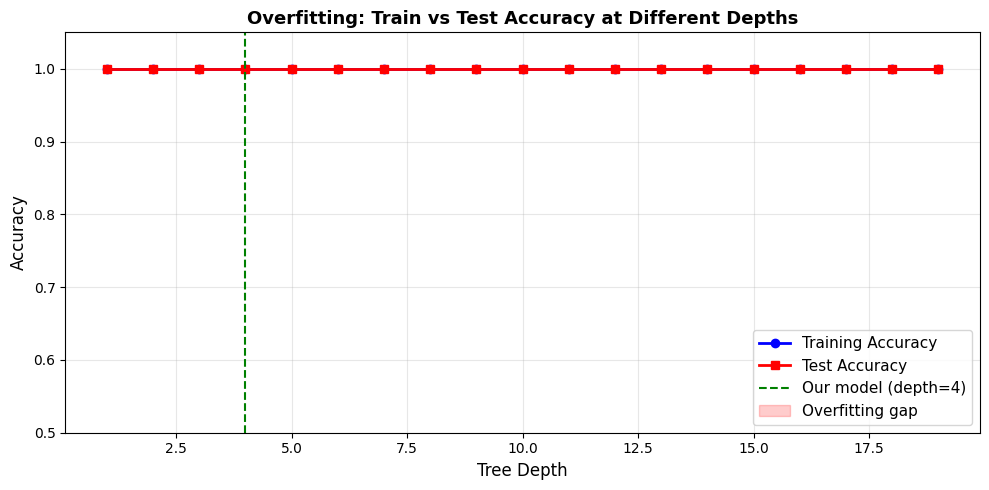

Best depth by test accuracy: 1
Notice: as depth increases past optimal, test accuracy drops = OVERFITTING


In [9]:
# Step 9: Overfitting Visualization — Depth vs Accuracy

depths = range(1, 20)
train_scores, test_scores = [], []

for d in depths:
    model = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  model.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, 'b-o', label='Training Accuracy', linewidth=2)
plt.plot(depths, test_scores,  'r-s', label='Test Accuracy',     linewidth=2)
plt.axvline(x=4, color='green', linestyle='--', linewidth=1.5, label='Our model (depth=4)')
plt.fill_between(depths, train_scores, test_scores,
                 where=[t > v for t, v in zip(train_scores, test_scores)],
                 alpha=0.2, color='red', label='Overfitting gap')

plt.xlabel('Tree Depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Overfitting: Train vs Test Accuracy at Different Depths', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.ylim(0.5, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('overfitting_curve.png', dpi=120, bbox_inches='tight')
plt.show()

best_depth = depths[np.argmax(test_scores)]
print(f"Best depth by test accuracy: {best_depth}")
print("Notice: as depth increases past optimal, test accuracy drops = OVERFITTING")

In [10]:
# Step 10: Predict New Emails — Practical Demo

new_emails = pd.DataFrame({
    'has_free_word':       [1, 0, 1, 0],
    'has_win_prize':       [1, 0, 0, 0],
    'exclamation_count':   [7, 1, 4, 0],
    'is_known_sender':     [0, 1, 0, 1],
    'has_suspicious_link': [1, 0, 1, 0],
    'word_count':          [35, 200, 60, 150]
})

email_descriptions = [
    "WIN a FREE iPhone NOW!!!!!!",
    "Meeting notes for tomorrow's standup",
    "FREE gift waiting for you!!! Click here",
    "Lunch plans for Friday?"
]

predictions = dt_good.predict(new_emails)
probabilities = dt_good.predict_proba(new_emails)

print("=" * 65)
print("LIVE EMAIL PREDICTION DEMO")
print("=" * 65)
for i, (desc, pred, prob) in enumerate(zip(email_descriptions, predictions, probabilities)):
    label = le.inverse_transform([pred])[0].upper()
    icon  = '🚫' if label == 'SPAM' else '✅'
    print(f"\nEmail {i+1}: \"{desc}\"")
    print(f"  Prediction : {icon} {label}")
    print(f"  Confidence : Ham={prob[0]:.0%}, Spam={prob[1]:.0%}")

LIVE EMAIL PREDICTION DEMO

Email 1: "WIN a FREE iPhone NOW!!!!!!"
  Prediction : 🚫 SPAM
  Confidence : Ham=0%, Spam=100%

Email 2: "Meeting notes for tomorrow's standup"
  Prediction : ✅ HAM
  Confidence : Ham=100%, Spam=0%

Email 3: "FREE gift waiting for you!!! Click here"
  Prediction : 🚫 SPAM
  Confidence : Ham=0%, Spam=100%

Email 4: "Lunch plans for Friday?"
  Prediction : ✅ HAM
  Confidence : Ham=100%, Spam=0%


---

## Master Cheat Sheet — Everything in One Place

| Concept | One-liner |
|---------|----------|
| Decision Tree | Flowchart the algorithm builds from data |
| Entropy | Chaos measure — 0 = pure, 1 = totally mixed |
| Gini Impurity | Wrong-guess probability — 0 = pure, 0.5 = mixed |
| Information Gain | Entropy(parent) − weighted Entropy(children) |
| Gain Ratio | IG / Split Info — fixes bias toward high-cardinality features |
| Chi-Square | Tests if a feature's pattern is statistically real or random noise |
| Root Node | Feature with highest IG becomes first split |
| Stopping Criteria | Pure node / max_depth / min_samples / no IG improvement |
| Overfitting | Train ≫ Test accuracy — tree memorized data |
| Pre-Pruning | Stop tree early (max_depth, min_samples_split, min_samples_leaf) |
| Post-Pruning | Grow full tree then cut branches (ccp_alpha parameter) |
| Feature Importance | How much each feature reduced impurity across all splits |
| Visibility | Can explain every prediction path — critical in regulated domains |

---

## Algorithm Quick Pick

| Your data / need | Use |
|-----------------|-----|
| General classification | CART (sklearn) with `criterion='gini'` |
| Want entropy-based splits | CART with `criterion='entropy'` |
| Many categories, need merging | CHAID |
| Bias in high-cardinality features | C4.5 (Gain Ratio) |
| Overfitting | Add `max_depth` + tune `ccp_alpha` |

---

## Quick Math Reference

```
Entropy    = -Σ p × log₂(p)                        range: [0, 1]
Gini       = 1 - Σ p²                               range: [0, 0.5]
Info Gain  = H(parent) - Σ (n_child/n) × H(child)
Gain Ratio = Info Gain / Split Info
Chi-Square = Σ (Observed - Expected)² / Expected
```


---
# PART 2: Advanced Topics
---

## 12. Pruning — Cutting the Tree to Prevent Overfitting

### What is Pruning?

**Analogy:**
> Think of a tree in your garden. If you let it grow freely, branches go everywhere — it looks messy and wastes energy. A gardener **prunes** (cuts) unnecessary branches to keep it healthy and focused.

Same idea in ML — we **cut unnecessary branches** from the decision tree so it doesn't overfit.

---

### Two Types of Pruning

```
PRE-PRUNING                         POST-PRUNING
(Stop early — don't grow)           (Grow fully — then cut back)

Build tree →                        Build full tree →
  At each split, ask:                 After building, ask:
  "Is this split worth it?"           "Does removing this branch
  If NO → stop here (make leaf)        hurt accuracy? If NO → cut it"
```

---

### A) Pre-Pruning (Early Stopping)

Stop the tree from growing further using rules **during** training.

| Parameter | What it does | Example |
|-----------|-------------|---------|
| `max_depth` | Max levels the tree can have | `max_depth=4` |
| `min_samples_split` | Min samples needed to split a node | `min_samples_split=10` |
| `min_samples_leaf` | Min samples a leaf must have | `min_samples_leaf=5` |
| `max_features` | Max features considered per split | `max_features='sqrt'` |
| `max_leaf_nodes` | Max total leaves in the tree | `max_leaf_nodes=20` |

**Example:**
```
Node has 4 samples → min_samples_split=10
→ Tree says: "Not enough samples to split, make this a leaf"
→ Prevents tiny, noisy splits
```

---

### B) Post-Pruning (Cost Complexity Pruning)

Grow the full tree first, then **go back and cut branches** that don't add value.

**How it works:**
```
Full tree accuracy  = 94%
Remove branch X → accuracy = 93.5%  → Cut it! (almost same, simpler tree)
Remove branch Y → accuracy = 88%    → Keep it! (too much accuracy loss)
```

**The formula used:**
```
Cost = Error_rate + alpha × number_of_leaves

alpha (ccp_alpha) controls the trade-off:
  alpha = 0   → no pruning (full tree)
  alpha = 0.1 → heavy pruning (very simple tree)
```

**In sklearn:** `ccp_alpha` parameter — higher value = more pruning

---

### Visual Summary of Pruning

```
BEFORE PRUNING:                    AFTER PRUNING:
        A                                  A
       / \                                / \
      B   C                              B   C
     / \   \                           (leaf)(leaf)
    D   E   F
   / \
  G   H  ← These tiny branches
           only match 2-3 samples
           → PRUNED (removed)
```

---

### When to Use Which?

| Situation | Use |
|-----------|-----|
| Want fast training | Pre-pruning |
| Want best accuracy | Post-pruning (ccp_alpha) |
| Production systems | Both combined |
| Teaching/demos | Pre-pruning (simpler to explain) |


---

## 13. Chi-Square Test for Feature Selection in Decision Trees

### What is Chi-Square (χ²)?

**Used in:** CHAID algorithm (Chi-square Automatic Interaction Detection)

**Simple Definition:** Chi-Square tests whether a feature has a **statistically significant relationship** with the target variable, or if it's just random chance.

**Analogy:**
> You flip a coin 10 times and get 8 heads. Is the coin biased or just lucky?
> Chi-square answers: **"Is this pattern real or random?"**

---

### The Core Idea

```
Observed values  = what actually happened in the data
Expected values  = what WOULD happen if there was NO relationship

If Observed ≈ Expected → feature is NOT useful (random)
If Observed ≠ Expected → feature IS useful (real pattern)
```

---

### Step-by-Step Manual Example

**Dataset: 20 emails — Does "has_free_word" relate to Spam/Ham?**

**Step 1: Observed Table (actual counts)**

|  | Spam | Ham | Total |
|--|------|-----|-------|
| FREE = YES | 12 | 3 | 15 |
| FREE = NO | 2 | 3 | 5 |
| **Total** | **14** | **6** | **20** |

**Step 2: Expected Table (if no relationship)**
```
Expected = (Row Total × Column Total) / Grand Total

E(FREE=YES, Spam) = (15 × 14) / 20 = 10.5
E(FREE=YES, Ham)  = (15 × 6)  / 20 = 4.5
E(FREE=NO,  Spam) = (5  × 14) / 20 = 3.5
E(FREE=NO,  Ham)  = (5  × 6)  / 20 = 1.5
```

**Step 3: Chi-Square Formula**
```
χ² = Σ [ (Observed - Expected)² / Expected ]

χ² = (12-10.5)²/10.5  +  (3-4.5)²/4.5  +  (2-3.5)²/3.5  +  (3-1.5)²/1.5
   =  1.5²/10.5       +  1.5²/4.5      +  1.5²/3.5      +  1.5²/1.5
   =  0.214  +  0.5  +  0.643  +  1.5
   =  2.857
```

**Step 4: Compare to Critical Value**
```
Degrees of Freedom (df) = (rows-1) × (cols-1) = (2-1) × (2-1) = 1

At 95% confidence, critical value for df=1 → 3.841

Our χ² = 2.857 < 3.841
→ Not statistically significant at 95% (borderline)
→ With more data, "FREE" would likely be significant
```

---

### Chi-Square vs Information Gain — Key Difference

| Aspect | Information Gain | Chi-Square |
|--------|-----------------|------------|
| What it measures | How much entropy is reduced | Is the pattern statistically real? |
| Used in | ID3, C4.5 | CHAID |
| Output | A number (higher = better) | p-value (lower = more significant) |
| Best for | Continuous + categorical | Categorical features only |
| Handles noise? | No (splits on everything) | Yes (ignores random patterns) |
| Merges similar categories? | No | Yes (CHAID merges similar branches) |

---

### CHAID — The Chi-Square Tree Algorithm

```
Normal Decision Tree:         CHAID Tree:
  Binary splits only            Can have 3+ branches per node
  (YES / NO)                    (LOW / MEDIUM / HIGH)

  has_free_word?                exclamation_count?
    YES → ...                     0-1    → HAM
    NO  → ...                     2-4    → UNCERTAIN
                                  5+     → SPAM
```

**CHAID merges categories** that are NOT statistically different (using Chi-Square), making the tree simpler and more interpretable.

---

### When to Use Chi-Square / CHAID?

- Data has many **categorical features**
- You want to **test statistical significance** of splits
- Survey/market research data
- Medical studies where statistical rigor matters


---

## 14. Decision Tree Algorithms Compared (ID3 vs C4.5 vs CART vs CHAID)

| Feature | ID3 | C4.5 | CART | CHAID |
|---------|-----|------|------|-------|
| Split criteria | Info Gain | Gain Ratio | Gini / MSE | Chi-Square |
| Output | Classification | Classification | Classification + Regression | Classification |
| Splits | Multi-way | Multi-way | Binary only | Multi-way |
| Missing values | No | Yes | Yes | Yes |
| Pruning | No | Yes | Yes (ccp_alpha) | Yes |
| sklearn? | No | No | **YES** | No |
| Best for | Teaching | Categorical data | General use | Survey data |

**sklearn uses CART** — that's why it uses Gini by default and always makes binary splits.

---

## 15. Stopping Criteria — When Does the Tree Stop Growing?

The tree stops splitting a node when ANY of these are true:

```
1. Node is PURE → all samples are same class (entropy = 0)
2. max_depth reached → no more levels allowed
3. min_samples_split → node has too few samples to split
4. min_samples_leaf → split would create a too-small leaf
5. No improvement → best split gives IG = 0
```

---

## 16. Gain Ratio — Fixing a Bias in Information Gain

**Problem with plain Information Gain:**
A feature like "Email ID" has a unique value per row → splits data perfectly → gets highest IG → but is useless for prediction!

**Gain Ratio fixes this:**
```
Gain Ratio = Information Gain / Split Information

Split Information = -Σ (|Sv|/|S|) × log₂(|Sv|/|S|)
                  (penalizes features with many unique values)
```

High Split Info = feature has many unique values → penalty applied → Gain Ratio drops

**Used in:** C4.5 algorithm

---

## 17. Handling Continuous Features

For a continuous feature like `word_count = [35, 80, 120, 200, 250]`:

The tree tries all possible thresholds:
```
Try: word_count <= 57   → IG = 0.12
Try: word_count <= 100  → IG = 0.31  ← BEST
Try: word_count <= 160  → IG = 0.22
Try: word_count <= 225  → IG = 0.18

→ Splits at word_count <= 100
```

Thresholds tried = midpoints between sorted unique values.

---

## 18. Feature Importance Score

After training, sklearn gives each feature an importance score:

```
Importance of feature X = 
  Sum of (weighted impurity decrease) at all nodes where X was used

                        n_samples_node
  = Σ nodes using X:  ─────────────── × (impurity_before - weighted_impurity_after)
                        n_samples_total
```

**Higher score = feature appeared higher in tree and split more data**

This is why it's also called **Mean Decrease in Impurity (MDI)**.

---

## 19. Complete Algorithm Comparison Table

| When to choose | Algorithm |
|----------------|-----------|
| Quick baseline, any data | CART (sklearn default) |
| Many categorical features | C4.5 or CHAID |
| Need statistical significance | CHAID |
| Teaching entropy concept | ID3 |
| Need regression output | CART with `criterion='squared_error'` |
| Overfitting is a concern | Add max_depth + ccp_alpha |
| Very large dataset | Random Forest (ensemble of CART trees) |


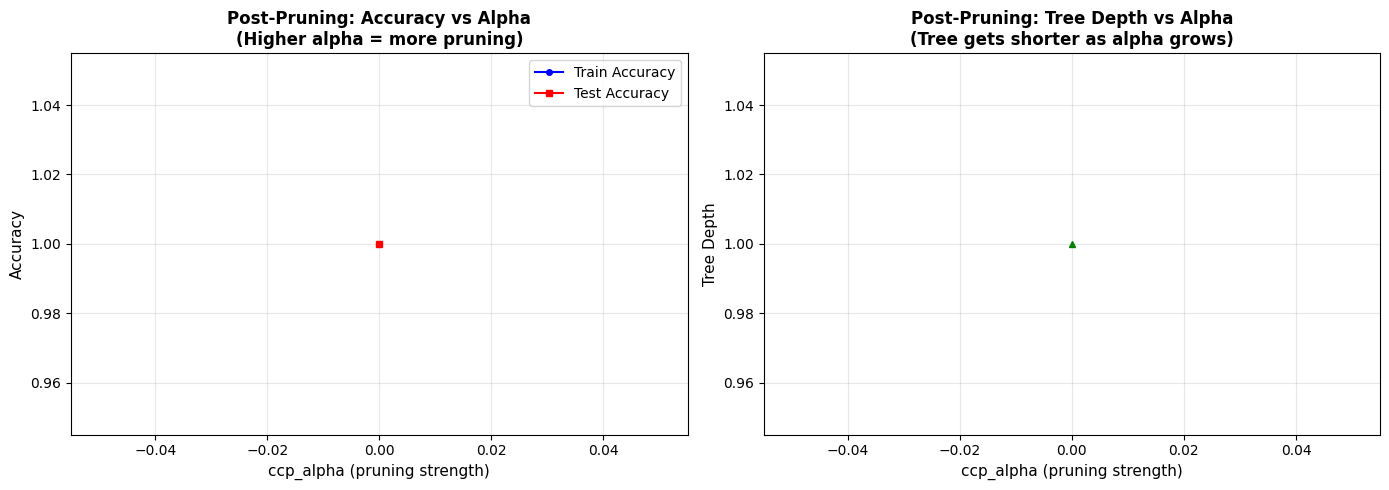

Best ccp_alpha: 0.0000
  → Test Accuracy : 100.0%
  → Tree Depth    : 1

Pruned model test accuracy: 100.0%


In [11]:
# Step 11: Post-Pruning with ccp_alpha (Cost Complexity Pruning)

# Get pruning path — shows how tree changes as alpha increases
path = dt_overfit.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]  # remove last (trivial tree)

# Train a tree for each alpha value
pruned_train_scores = []
pruned_test_scores  = []
pruned_depths       = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(criterion='entropy', ccp_alpha=alpha, random_state=42)
    model.fit(X_train, y_train)
    pruned_train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    pruned_test_scores.append(accuracy_score(y_test,  model.predict(X_test)))
    pruned_depths.append(model.get_depth())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy vs alpha
axes[0].plot(ccp_alphas, pruned_train_scores, 'b-o', label='Train Accuracy', markersize=4)
axes[0].plot(ccp_alphas, pruned_test_scores,  'r-s', label='Test Accuracy',  markersize=4)
axes[0].set_xlabel('ccp_alpha (pruning strength)', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Post-Pruning: Accuracy vs Alpha\n(Higher alpha = more pruning)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Tree depth vs alpha
axes[1].plot(ccp_alphas, pruned_depths, 'g-^', markersize=4)
axes[1].set_xlabel('ccp_alpha (pruning strength)', fontsize=11)
axes[1].set_ylabel('Tree Depth', fontsize=11)
axes[1].set_title('Post-Pruning: Tree Depth vs Alpha\n(Tree gets shorter as alpha grows)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('post_pruning.png', dpi=120, bbox_inches='tight')
plt.show()

# Find best alpha
best_alpha_idx = np.argmax(pruned_test_scores)
best_alpha     = ccp_alphas[best_alpha_idx]
print(f"Best ccp_alpha: {best_alpha:.4f}")
print(f"  → Test Accuracy : {pruned_test_scores[best_alpha_idx]:.1%}")
print(f"  → Tree Depth    : {pruned_depths[best_alpha_idx]}")

# Train final pruned model
dt_pruned = DecisionTreeClassifier(criterion='entropy', ccp_alpha=best_alpha, random_state=42)
dt_pruned.fit(X_train, y_train)
print(f"\nPruned model test accuracy: {accuracy_score(y_test, dt_pruned.predict(X_test)):.1%}")

In [12]:
# Step 12: Chi-Square Test — Manual Calculation + scipy verification

from scipy.stats import chi2_contingency
import scipy.stats as stats

print("=" * 65)
print("CHI-SQUARE TEST: Is a feature statistically significant?")
print("=" * 65)

features_to_test = ['has_free_word', 'has_win_prize', 'has_suspicious_link',
                    'is_known_sender', 'exclamation_count']

results = []
for feat in features_to_test:
    # Binarize continuous features at median
    if df[feat].nunique() > 2:
        threshold = df[feat].median()
        col = (df[feat] > threshold).astype(int)
        feat_label = f"{feat} > {threshold}"
    else:
        col = df[feat]
        feat_label = feat

    # Contingency table
    ct = pd.crosstab(col, df['label'])

    # Chi-square test
    chi2, p_value, dof, expected = chi2_contingency(ct)

    significant = "YES ✓" if p_value < 0.05 else "NO  ✗"
    results.append({
        'Feature': feat,
        'Chi2': round(chi2, 3),
        'p-value': round(p_value, 4),
        'Significant?': significant
    })

results_df = pd.DataFrame(results).sort_values('Chi2', ascending=False)
print(results_df.to_string(index=False))

print("\nInterpretation:")
print("  p-value < 0.05 → Feature is statistically significant → USE IT")
print("  p-value > 0.05 → Feature may be random noise → SKIP IT")
print("\n  Chi2 value: higher = stronger relationship with label")

CHI-SQUARE TEST: Is a feature statistically significant?
            Feature    Chi2  p-value Significant?
  exclamation_count 196.020      0.0        YES ✓
      has_free_word 109.531      0.0        YES ✓
    is_known_sender 100.860      0.0        YES ✓
      has_win_prize  98.408      0.0        YES ✓
has_suspicious_link  78.611      0.0        YES ✓

Interpretation:
  p-value < 0.05 → Feature is statistically significant → USE IT
  p-value > 0.05 → Feature may be random noise → SKIP IT

  Chi2 value: higher = stronger relationship with label


In [13]:
# Step 13: Gain Ratio vs Information Gain comparison

print("=" * 65)
print("GAIN RATIO vs INFORMATION GAIN — Handling High-Cardinality Features")
print("=" * 65)

def compute_split_info(df, feature):
    """Split Information penalizes features with many unique values."""
    n = len(df)
    value_counts = df[feature].value_counts()
    split_info = -sum((count/n) * np.log2(count/n + 1e-10) for count in value_counts)
    return round(split_info, 4)

def compute_gain_ratio(df, feature, labels):
    threshold = df[feature].median()
    left_labels  = labels[df[feature] <= threshold].tolist()
    right_labels = labels[df[feature] >  threshold].tolist()
    ig = compute_information_gain(labels.tolist(), left_labels, right_labels)
    split_info = compute_split_info(df, feature)
    if split_info == 0:
        return 0
    return round(ig / split_info, 4)

# Add a fake high-cardinality feature (like email ID — useless but high IG)
df_test = df.copy()
df_test['email_id'] = range(len(df_test))  # unique per row — useless feature!

labels = df_test['label']
test_features = features + ['email_id']

print(f"\n{'Feature':<25} {'Info Gain':>12} {'Gain Ratio':>12} {'Note'}")
print("-" * 70)

for feat in test_features:
    threshold = df_test[feat].median()
    left  = labels[df_test[feat] <= threshold].tolist()
    right = labels[df_test[feat] >  threshold].tolist()
    ig = compute_information_gain(labels.tolist(), left, right)
    gr = compute_gain_ratio(df_test, feat, labels)
    note = " ← USELESS but high IG!" if feat == 'email_id' else ""
    print(f"{feat:<25} {ig:>12.4f} {gr:>12.4f}{note}")

print("\nGain Ratio penalizes 'email_id' — fixing the bias in plain Info Gain")

GAIN RATIO vs INFORMATION GAIN — Handling High-Cardinality Features

Feature                      Info Gain   Gain Ratio Note
----------------------------------------------------------------------
has_free_word                   0.4565       0.4565
has_win_prize                   0.4153       0.4253
exclamation_count               1.0000       0.3164
is_known_sender                 0.0000       0.0000
has_suspicious_link             0.3328       0.3546
word_count                      0.4426       0.0654
email_id                        0.0003       0.0000 ← USELESS but high IG!

Gain Ratio penalizes 'email_id' — fixing the bias in plain Info Gain
